# Autoregressive Moving Average (ARMA): Sunspots data

In [1]:
%matplotlib inline

In [2]:
import numpy as np
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

In [3]:
from statsmodels.graphics.api import qqplot

## Sunspots Data

In [4]:
print(sm.datasets.sunspots.NOTE)

::

    Number of Observations - 309 (Annual 1700 - 2008)
    Number of Variables - 1
    Variable name definitions::

        SUNACTIVITY - Number of sunspots for each year

    The data file contains a 'YEAR' variable that is not returned by load.



In [5]:
dta = sm.datasets.sunspots.load_pandas().data

In [6]:
dta.index = pd.Index(sm.tsa.datetools.dates_from_range('1700', '2008'))
del dta["YEAR"]

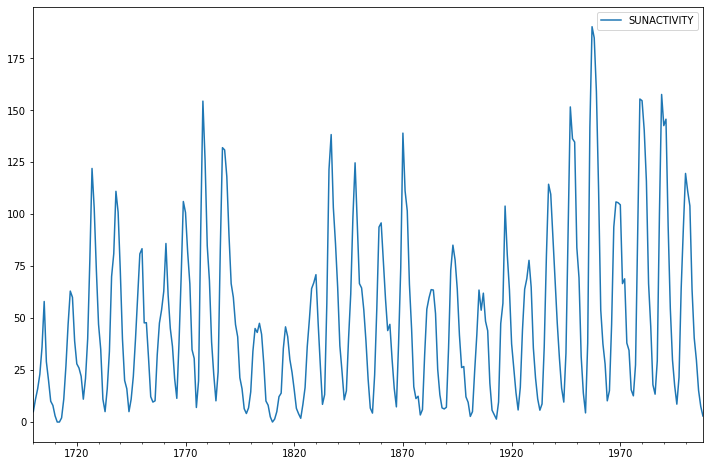

In [7]:
dta.plot(figsize=(12,8));

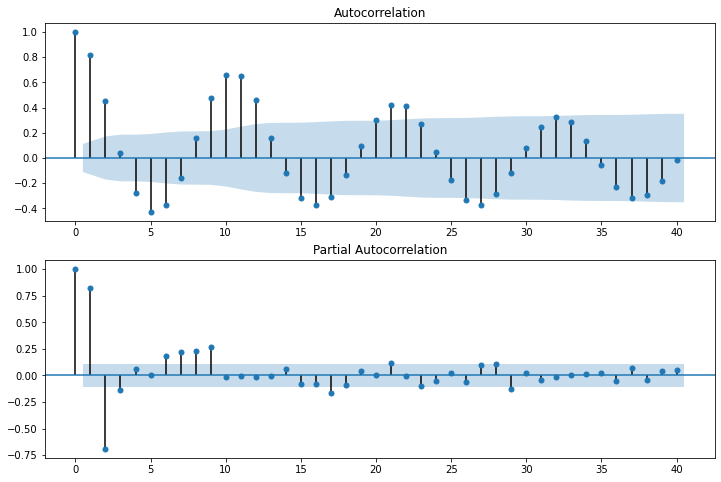

In [8]:
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(dta.values.squeeze(), lags=40, ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(dta, lags=40, ax=ax2)

In [9]:
arma_mod20 = ARIMA(dta, order=(2, 0, 0)).fit()
print(arma_mod20.params)

/home/travis/build/statsmodels/statsmodels/statsmodels/tsa/base/tsa_model.py:527: ValueWarning: No frequency information was provided, so inferred frequency A-DEC will be used.
  % freq, ValueWarning)
/home/travis/build/statsmodels/statsmodels/statsmodels/tsa/base/tsa_model.py:527: ValueWarning: No frequency information was provided, so inferred frequency A-DEC will be used.
  % freq, ValueWarning)
/home/travis/build/statsmodels/statsmodels/statsmodels/tsa/base/tsa_model.py:527: ValueWarning: No frequency information was provided, so inferred frequency A-DEC will be used.
  % freq, ValueWarning)


const      49.746203
ar.L1       1.390630
ar.L2      -0.688573
sigma2    274.727195
dtype: float64


In [10]:
arma_mod30 = ARIMA(dta, order=(3, 0, 0)).fit()

/home/travis/build/statsmodels/statsmodels/statsmodels/tsa/base/tsa_model.py:527: ValueWarning: No frequency information was provided, so inferred frequency A-DEC will be used.
  % freq, ValueWarning)
/home/travis/build/statsmodels/statsmodels/statsmodels/tsa/base/tsa_model.py:527: ValueWarning: No frequency information was provided, so inferred frequency A-DEC will be used.
  % freq, ValueWarning)
/home/travis/build/statsmodels/statsmodels/statsmodels/tsa/base/tsa_model.py:527: ValueWarning: No frequency information was provided, so inferred frequency A-DEC will be used.
  % freq, ValueWarning)


In [11]:
print(arma_mod20.aic, arma_mod20.bic, arma_mod20.hqic)

2622.637093617488 2637.570458725079 2628.607481462734


In [12]:
print(arma_mod30.params)

const      49.751916
ar.L1       1.300815
ar.L2      -0.508103
ar.L3      -0.129643
sigma2    270.100803
dtype: float64


In [13]:
print(arma_mod30.aic, arma_mod30.bic, arma_mod30.hqic)

2619.40362924499

 2638.070335629479 2626.8666140515475


* Does our model obey the theory?

In [14]:
sm.stats.durbin_watson(arma_mod30.resid.values)

1.9564893284487443

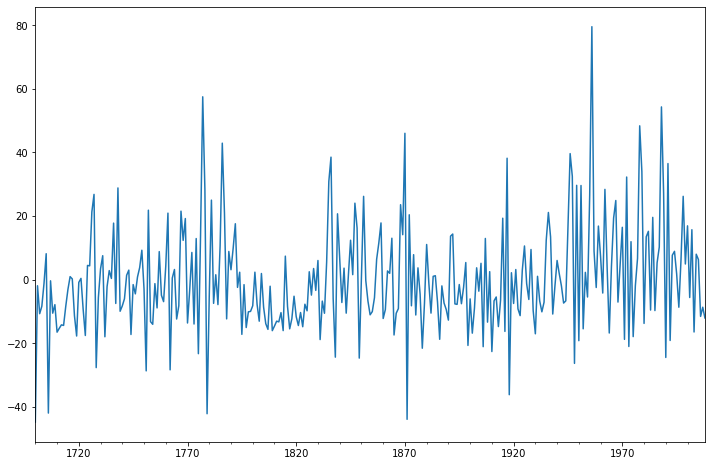

In [15]:
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111)
ax = arma_mod30.resid.plot(ax=ax);

In [16]:
resid = arma_mod30.resid

In [17]:
stats.normaltest(resid)

NormaltestResult(statistic=49.84412434485992, pvalue=1.501363733141781e-11)

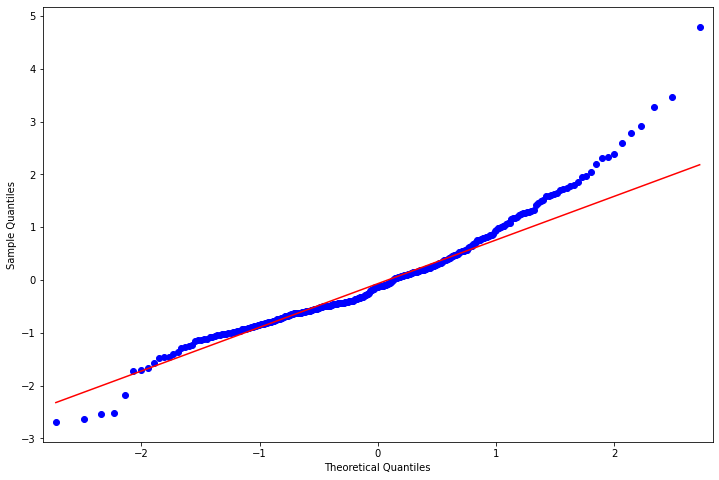

In [18]:
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111)
fig = qqplot(resid, line='q', ax=ax, fit=True)

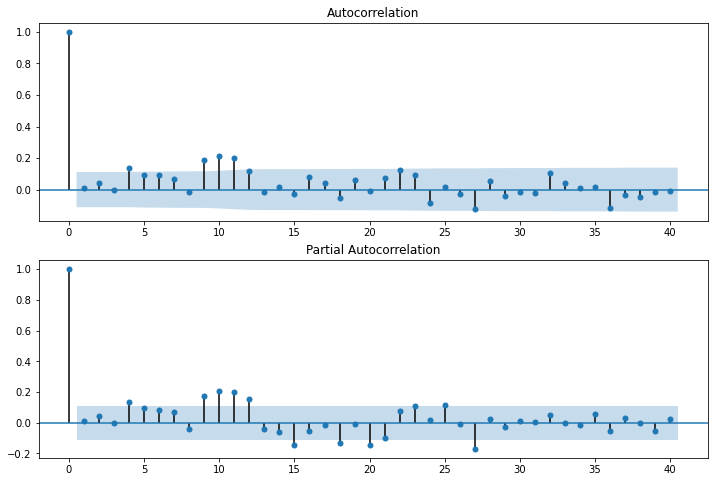

In [19]:
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(resid.values.squeeze(), lags=40, ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(resid, lags=40, ax=ax2)

In [20]:
r,q,p = sm.tsa.acf(resid.values.squeeze(), fft=True, qstat=True)
data = np.c_[range(1,41), r[1:], q, p]
table = pd.DataFrame(data, columns=['lag', "AC", "Q", "Prob(>Q)"])
print(table.set_index('lag'))

            AC          Q      Prob(>Q)
lag                                    
1.0   0.009173   0.026256  8.712767e-01
2.0   0.041798   0.573124  7.508404e-01
3.0  -0.001334   0.573683  9.024297e-01
4.0   0.136089   6.409004  1.706149e-01
5.0   0.092467   9.111806  1.046868e-01
6.0   0.091948  11.793188  6.674479e-02
7.0   0.068748  13.297148  6.519100e-02
8.0  -0.015020  13.369178  9.976291e-02
9.0   0.187592  24.641825  3.394016e-03
10.0  0.213716  39.321684  2.229753e-05
11.0  0.201081  52.360708  2.345370e-07
12.0  0.117182  56.803797  8.575653e-08
13.0 -0.014054  56.867925  1.894211e-07
14.0  0.015400  56.945178  3.998274e-07
15.0 -0.024968  57.148942  7.742609e-07
16.0  0.080915  59.296336  6.873316e-07
17.0  0.041137  59.853280  1.111137e-06
18.0 -0.052022  60.746987  1.548687e-06
19.0  0.062497  62.041294  1.831911e-06
20.0 -0.010302  62.076582  3.381727e-06
21.0  0.074453  63.926259  3.194035e-06
22.0  0.124954  69.154307  8.979855e-07
23.0  0.093162  72.070599  5.800691e-07


/home/travis/build/statsmodels/statsmodels/statsmodels/tsa/stattools.py:657: FutureWarning: The default number of lags is changing from 40 tomin(int(10 * np.log10(nobs)), nobs - 1) after 0.12is released. Set the number of lags to an integer to  silence this warning.
  FutureWarning,


* This indicates a lack of fit.

* In-sample dynamic prediction. How good does our model do?

In [21]:
predict_sunspots = arma_mod30.predict('1990', '2012', dynamic=True)
print(predict_sunspots)

1990-12-31    167.047946
1991-12-31    140.994097
1992-12-31     94.860809
1993-12-31     46.863131
1994-12-31     11.245227
1995-12-31     -4.718418
1996-12-31     -1.164010
1997-12-31     16.188419
1998-12-31     39.024289
1999-12-31     59.451892
2000-12-31     72.171813
2001-12-31     75.378224
2002-12-31     70.437834
2003-12-31     60.733062
2004-12-31     50.203490
2005-12-31     42.077983
2006-12-31     38.116472
2007-12-31     38.456966
2008-12-31     41.966160
2009-12-31     46.871548
2010-12-31     51.425374
2011-12-31     54.401670
2012-12-31     55.323515
Freq: A-DEC, Name: predicted_mean, dtype: float64


In [22]:
def mean_forecast_err(y, yhat):
    return y.sub(yhat).mean()

In [23]:
mean_forecast_err(dta.SUNACTIVITY, predict_sunspots)

5.63497970718827

### Exercise: Can you obtain a better fit for the Sunspots model? (Hint: sm.tsa.AR has a method select_order)

### Simulated ARMA(4,1): Model Identification is Difficult

In [24]:
from statsmodels.tsa.arima_process import ArmaProcess

In [25]:
np.random.seed(1234)
# include zero-th lag
arparams = np.array([1, .75, -.65, -.55, .9])
maparams = np.array([1, .65])

Let's make sure this model is estimable.

In [26]:
arma_t = ArmaProcess(arparams, maparams)

In [27]:
arma_t.isinvertible

True

In [28]:
arma_t.isstationary

False

* What does this mean?

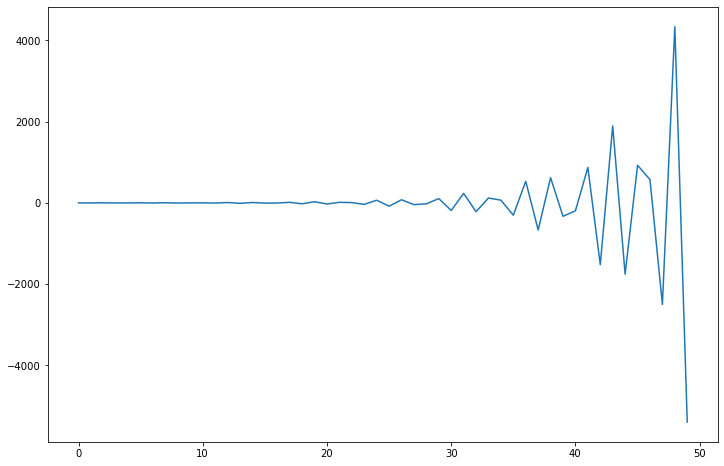

In [29]:
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111)
ax.plot(arma_t.generate_sample(nsample=50));

In [30]:
arparams = np.array([1, .35, -.15, .55, .1])
maparams = np.array([1, .65])
arma_t = ArmaProcess(arparams, maparams)
arma_t.isstationary

True

In [31]:
arma_rvs = arma_t.generate_sample(nsample=500, burnin=250, scale=2.5)

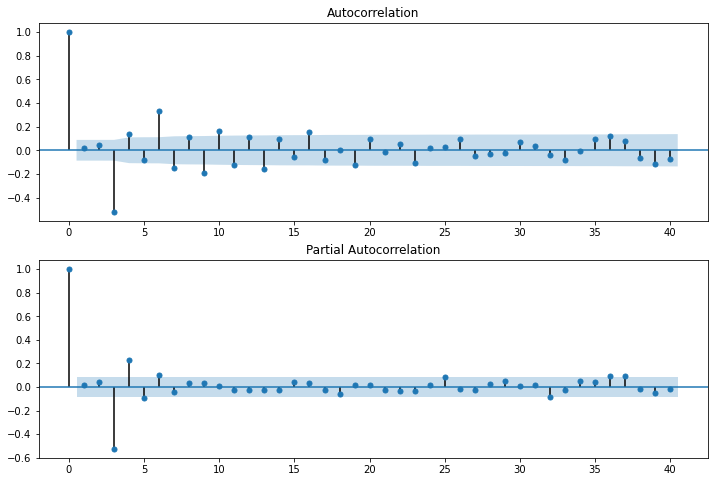

In [32]:
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(arma_rvs, lags=40, ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(arma_rvs, lags=40, ax=ax2)

* For mixed ARMA processes the Autocorrelation function is a mixture of exponentials and damped sine waves after (q-p) lags.
* The partial autocorrelation function is a mixture of exponentials and dampened sine waves after (p-q) lags.

In [33]:
arma11 = ARIMA(arma_rvs, order=(1, 0, 1)).fit()
resid = arma11.resid
r,q,p = sm.tsa.acf(resid, fft=True, qstat=True)
data = np.c_[range(1,41), r[1:], q, p]
table = pd.DataFrame(data, columns=['lag', "AC", "Q", "Prob(>Q)"])
print(table.set_index('lag'))

/home/travis/build/statsmodels/statsmodels/statsmodels/tsa/statespace/sarimax.py:962: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/travis/build/statsmodels/statsmodels/statsmodels/tsa/statespace/sarimax.py:974: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


            AC           Q      Prob(>Q)
lag                                     
1.0  -0.001237    0.000769  9.778720e-01
2.0   0.052362    1.382680  5.009044e-01
3.0  -0.522177  139.088740  5.942093e-30
4.0   0.146504  149.950207  2.086400e-31
5.0  -0.091176  154.165506  1.732243e-31
6.0   0.337059  211.889761  5.572512e-43
7.0  -0.160917  225.073318  5.524303e-45
8.0   0.116135  231.954028  1.143059e-45
9.0  -0.195352  251.462622  4.899528e-49
10.0  0.166409  265.647615  2.763265e-51
11.0 -0.126467  273.857103  2.769839e-52
12.0  0.115015  280.661042  5.338855e-53
13.0 -0.159302  293.740355  4.903046e-55
14.0  0.095847  298.484922  2.446471e-55
15.0 -0.062853  300.529423  4.338831e-55
16.0  0.159243  313.680142  3.721233e-57
17.0 -0.089423  317.835686  2.319071e-57
18.0  0.002506  317.838956  1.019355e-56
19.0 -0.124735  325.958019  9.305321e-58
20.0  0.093958  330.574407  4.418019e-58
21.0 -0.016214  330.712170  1.709813e-57
22.0  0.054804  332.289295  3.282316e-57
23.0 -0.110590  

/home/travis/build/statsmodels/statsmodels/statsmodels/tsa/stattools.py:657: FutureWarning: The default number of lags is changing from 40 tomin(int(10 * np.log10(nobs)), nobs - 1) after 0.12is released. Set the number of lags to an integer to  silence this warning.
  FutureWarning,


In [34]:
arma41 = ARIMA(arma_rvs, order=(4, 0, 1)).fit()
resid = arma41.resid
r,q,p = sm.tsa.acf(resid, fft=True, qstat=True)
data = np.c_[range(1,41), r[1:], q, p]
table = pd.DataFrame(data, columns=['lag', "AC", "Q", "Prob(>Q)"])
print(table.set_index('lag'))

            AC          Q  Prob(>Q)
lag                                
1.0  -0.007892   0.031328  0.859510
2.0   0.004137   0.039956  0.980220
3.0   0.018093   0.205289  0.976731
4.0  -0.006770   0.228480  0.993951
5.0   0.018118   0.394932  0.995468
6.0   0.050692   1.700600  0.945075
7.0   0.010254   1.754134  0.972188
8.0  -0.011204   1.818176  0.986088
9.0   0.020289   2.028607  0.991007
10.0  0.001029   2.029149  0.996112
11.0 -0.014036   2.130277  0.997983
12.0 -0.023856   2.423003  0.998427
13.0 -0.002109   2.425296  0.999339
14.0 -0.018781   2.607473  0.999590
15.0  0.011316   2.673741  0.999805
16.0  0.042159   3.595477  0.999443
17.0  0.007942   3.628257  0.999734
18.0 -0.074310   6.503823  0.993686
19.0 -0.023379   6.789041  0.995256
20.0  0.002398   6.792048  0.997313
21.0  0.000486   6.792172  0.998516
22.0  0.017953   6.961418  0.999024
23.0 -0.038575   7.744411  0.998744
24.0 -0.029816   8.213174  0.998860
25.0  0.077849  11.415634  0.990676
26.0  0.040407  12.280225  0

/home/travis/build/statsmodels/statsmodels/statsmodels/tsa/stattools.py:657: FutureWarning: The default number of lags is changing from 40 tomin(int(10 * np.log10(nobs)), nobs - 1) after 0.12is released. Set the number of lags to an integer to  silence this warning.
  FutureWarning,


### Exercise: How good of in-sample prediction can you do for another series, say, CPI

In [35]:
macrodta = sm.datasets.macrodata.load_pandas().data
macrodta.index = pd.Index(sm.tsa.datetools.dates_from_range('1959Q1', '2009Q3'))
cpi = macrodta["cpi"]

#### Hint: 

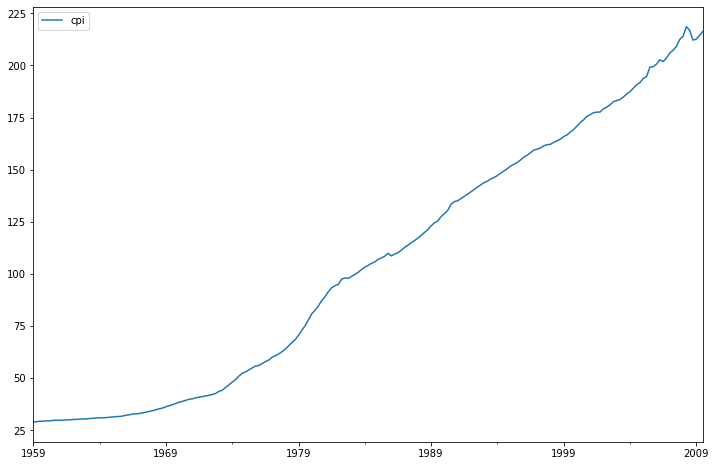

In [36]:
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111)
ax = cpi.plot(ax=ax);
ax.legend();

P-value of the unit-root test, resoundingly rejects the null of a unit-root.

In [37]:
print(sm.tsa.adfuller(cpi)[1])

0.9904328188337421
